In [1]:
import sys
!{sys.executable} -m pip install numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


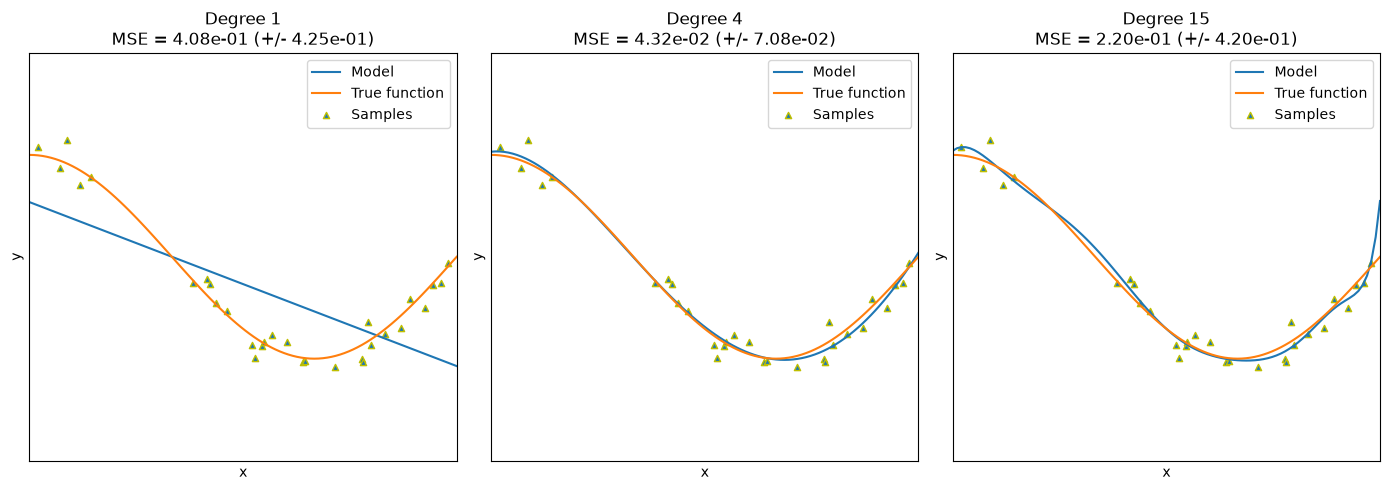

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


# True function
def true_fun(X):
    return np.cos(1.5 * np.pi * X)


# Set random seed
np.random.seed(0)

# Number of samples
n_samples = 30

# Polynomial degrees
degrees = [1, 4, 15]

# Generate random data
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1


# Create figure
plt.figure(figsize=(14, 5))


# Train models for different polynomial degrees
for i in range(len(degrees)):

    ax = plt.subplot(1, len(degrees), i + 1)

    plt.setp(ax, xticks=(), yticks=())

    # Polynomial features
    polynomial_features = PolynomialFeatures(
        degree=degrees[i],
        include_bias=False
    )

    # Linear regression
    linear_regression = LinearRegression()

    # Create pipeline
    pipeline = Pipeline([
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression)
    ])

    # Train model
    pipeline.fit(X[:, np.newaxis], y)

    # Cross-validation
    scores = cross_val_score(
        pipeline,
        X[:, np.newaxis],
        y,
        scoring="neg_mean_squared_error",
        cv=10
    )

    # Test data
    X_test = np.linspace(0, 1, 100)

    # Plot model prediction
    plt.plot(
        X_test,
        pipeline.predict(X_test[:, np.newaxis]),
        label="Model"
    )

    # Plot true function
    plt.plot(
        X_test,
        true_fun(X_test),
        label="True function"
    )

    # Plot sample data
    plt.scatter(
        X,
        y,
        edgecolor="y",
        s=20,
        marker="^",
        label="Samples"
    )

    # Labels
    plt.xlabel("x")
    plt.ylabel("y")

    plt.xlim((0, 1))
    plt.ylim((-2, 2))

    plt.legend(loc="best")

    # Display MSE
    plt.title(
        "Degree {}\nMSE = {:.2e} (+/- {:.2e})".format(
            degrees[i],
            -scores.mean(),
            scores.std()
        )
    )


# Display all plots
plt.tight_layout()
plt.show()